In [1]:
from Scripts.Random_forest_nested import *
import pickle
import matplotlib.pyplot as plt
from scipy.stats import randint
import seaborn as sns
import pandas as pd
import shap
import matplotlib.patheffects as pe
import numpy as np

In [2]:
df = pd.read_excel('../Data_preprocessing/all_time.xlsx', index_col=0)
X,y=df.loc[:,['scaled_nox', 'scaled_no2', 'scaled_formaldehyd', 'scaled_acetone',
       'scaled_acetald', 'scaled_bc', 'scaled_PM25', 'no2_street', 'nox_street',
       'pm25_street', 'bmi_6_yrs', 'gestational_age', 'mother\'s_education_1yr',
       'lrti_1y', 'genetic_risk_score_asthma', 'PCA1', 'PCA2']],df.verificeret_12y

In [3]:
list_parameters=[r'$\mathbf{NO_x}$',r'$\mathbf{NO_2}$',"Formaldehyd","Acetone","Acetald","Black Carbon",r'$\mathbf{PM_{2.5}}$',r"$\mathbf{Street \ NO_2}$",r"$\mathbf{Street \ NO_x}$",r"$\mathbf{Street \ PM_{2.5}}$","BMI","Gestational age","Mother Education","LRTI","PRS","PC 1","PC 2"]


In [4]:
replace_dict=dict(zip(X.columns,list_parameters))
X=X.rename(columns=replace_dict)

In [5]:
param_distributions = {
    'n_estimators':           [300],
    'max_depth':              randint(2, 6),
    'min_samples_leaf':       randint(5, 15),
    'max_features':           [0.5, 0.6, 0.7],
    'max_samples':            [0.5, 0.6, 0.7],
    # class_weight removed
}
dataframe=nested_cv_calibrated_rf(
    X, y,
    n_repeats=5,
    n_splits=5,
    n_neighbors_imputer=25,
    param_distributions=param_distributions)

fold   1/25  test AUC=0.701  BSS=+0.064  ICI=0.026   | apparent AUC=0.893
fold   2/25  test AUC=0.607  BSS=+0.031  ICI=0.017   | apparent AUC=0.942
fold   3/25  test AUC=0.604  BSS=+0.016  ICI=0.027   | apparent AUC=0.891
fold   4/25  test AUC=0.564  BSS=+0.015  ICI=0.023   | apparent AUC=0.907
fold   5/25  test AUC=0.693  BSS=+0.031  ICI=0.062   | apparent AUC=0.954
fold   6/25  test AUC=0.625  BSS=+0.037  ICI=0.026   | apparent AUC=0.891
fold   7/25  test AUC=0.668  BSS=+0.030  ICI=0.032   | apparent AUC=0.971
fold   8/25  test AUC=0.683  BSS=+0.035  ICI=0.050   | apparent AUC=0.861
fold   9/25  test AUC=0.600  BSS=+0.012  ICI=0.024   | apparent AUC=0.863
fold  10/25  test AUC=0.624  BSS=+0.008  ICI=0.036   | apparent AUC=0.944
fold  11/25  test AUC=0.582  BSS=-0.016  ICI=0.045   | apparent AUC=0.922
fold  12/25  test AUC=0.583  BSS=+0.003  ICI=0.034   | apparent AUC=0.899
fold  13/25  test AUC=0.607  BSS=+0.020  ICI=0.019   | apparent AUC=0.880
fold  14/25  test AUC=0.711  BSS=+0.05

In [6]:

# Swap the columns to create the reverse relationships (B->A, C->A, C->B)
df_flipped = dataframe["interaction_stats"].rename(columns={'feature_i': 'feature_j', 'feature_j': 'feature_i'})

# Combine them together
df_full = pd.concat([dataframe["interaction_stats"], df_flipped]).drop_duplicates()
features_to_drop = ["feature_i", "feature_j"]

matrix_r = df_full.pivot(index='feature_i', columns='feature_j', values='R_mean').rename_axis(None, axis=0).rename_axis(None, axis=1)
matrix_con = df_full.pivot(index='feature_i', columns='feature_j', values='sign_consistency').rename_axis(None, axis=0).rename_axis(None, axis=1)
matrix_effect = df_full.pivot(index='feature_i', columns='feature_j', values='abs_2phi_median').rename_axis(None, axis=0).rename_axis(None, axis=1)
matrix_effect_sign = df_full.pivot(index='feature_i', columns='feature_j', values='signed_2phi_median').rename_axis(None, axis=0).rename_axis(None, axis=1)
dominant_sign= df_full.pivot(index='feature_i', columns='feature_j', values='dominant_sign').rename_axis(None, axis=0).rename_axis(None, axis=1)

In [7]:
corr_matrix.abs()>0.3

NameError: name 'corr_matrix' is not defined

In [31]:
df_full

,feature_i,feature_j,R_median,R_q05,R_q95,R_mean,abs_2phi_median,signed_2phi_median,sign_consistency,dominant_sign,n_folds
0,Formaldehyd,PRS,0.201945,0.117757,0.320903,0.220077,0.005085,-0.000123,0.68,-1.0,25
1,Acetone,PRS,0.200657,0.067847,0.299416,0.198621,0.003580,-0.000092,0.60,-1.0,25
2,$\mathbf{Street \ NO_2}$,$\mathbf{Street \ NO_x}$,0.192610,0.000000,0.375800,0.172034,0.000799,-0.000683,0.88,-1.0,25
3,$\mathbf{Street \ NO_x}$,$\mathbf{Street \ PM_{2.5}}$,0.136259,0.000000,0.245982,0.120432,0.000373,-0.000236,0.76,-1.0,25
4,Acetald,PRS,0.133684,0.067373,0.223797,0.145589,0.001762,-0.000052,0.72,-1.0,25
...,...,...,...,...,...,...,...,...,...,...,...
131,Mother Education,Gestational age,0.021529,0.000000,0.064587,0.021578,0.000097,0.000000,0.40,1.0,25
132,LRTI,BMI,0.020682,0.001526,0.057591,0.024041,0.000206,-0.000004,0.52,-1.0,25
133,PRS,Mother Education,0.018752,0.000000,0.045454,0.019015,0.000213,0.000000,0.48,-1.0,25
134,Mother Education,$\mathbf{NO_x}$,0.017876,0.000000,0.094647,0.029419,0.000091,0.000000,0.44,1.0,25


In [20]:
corr_matrix=X.corr(method="spearman")

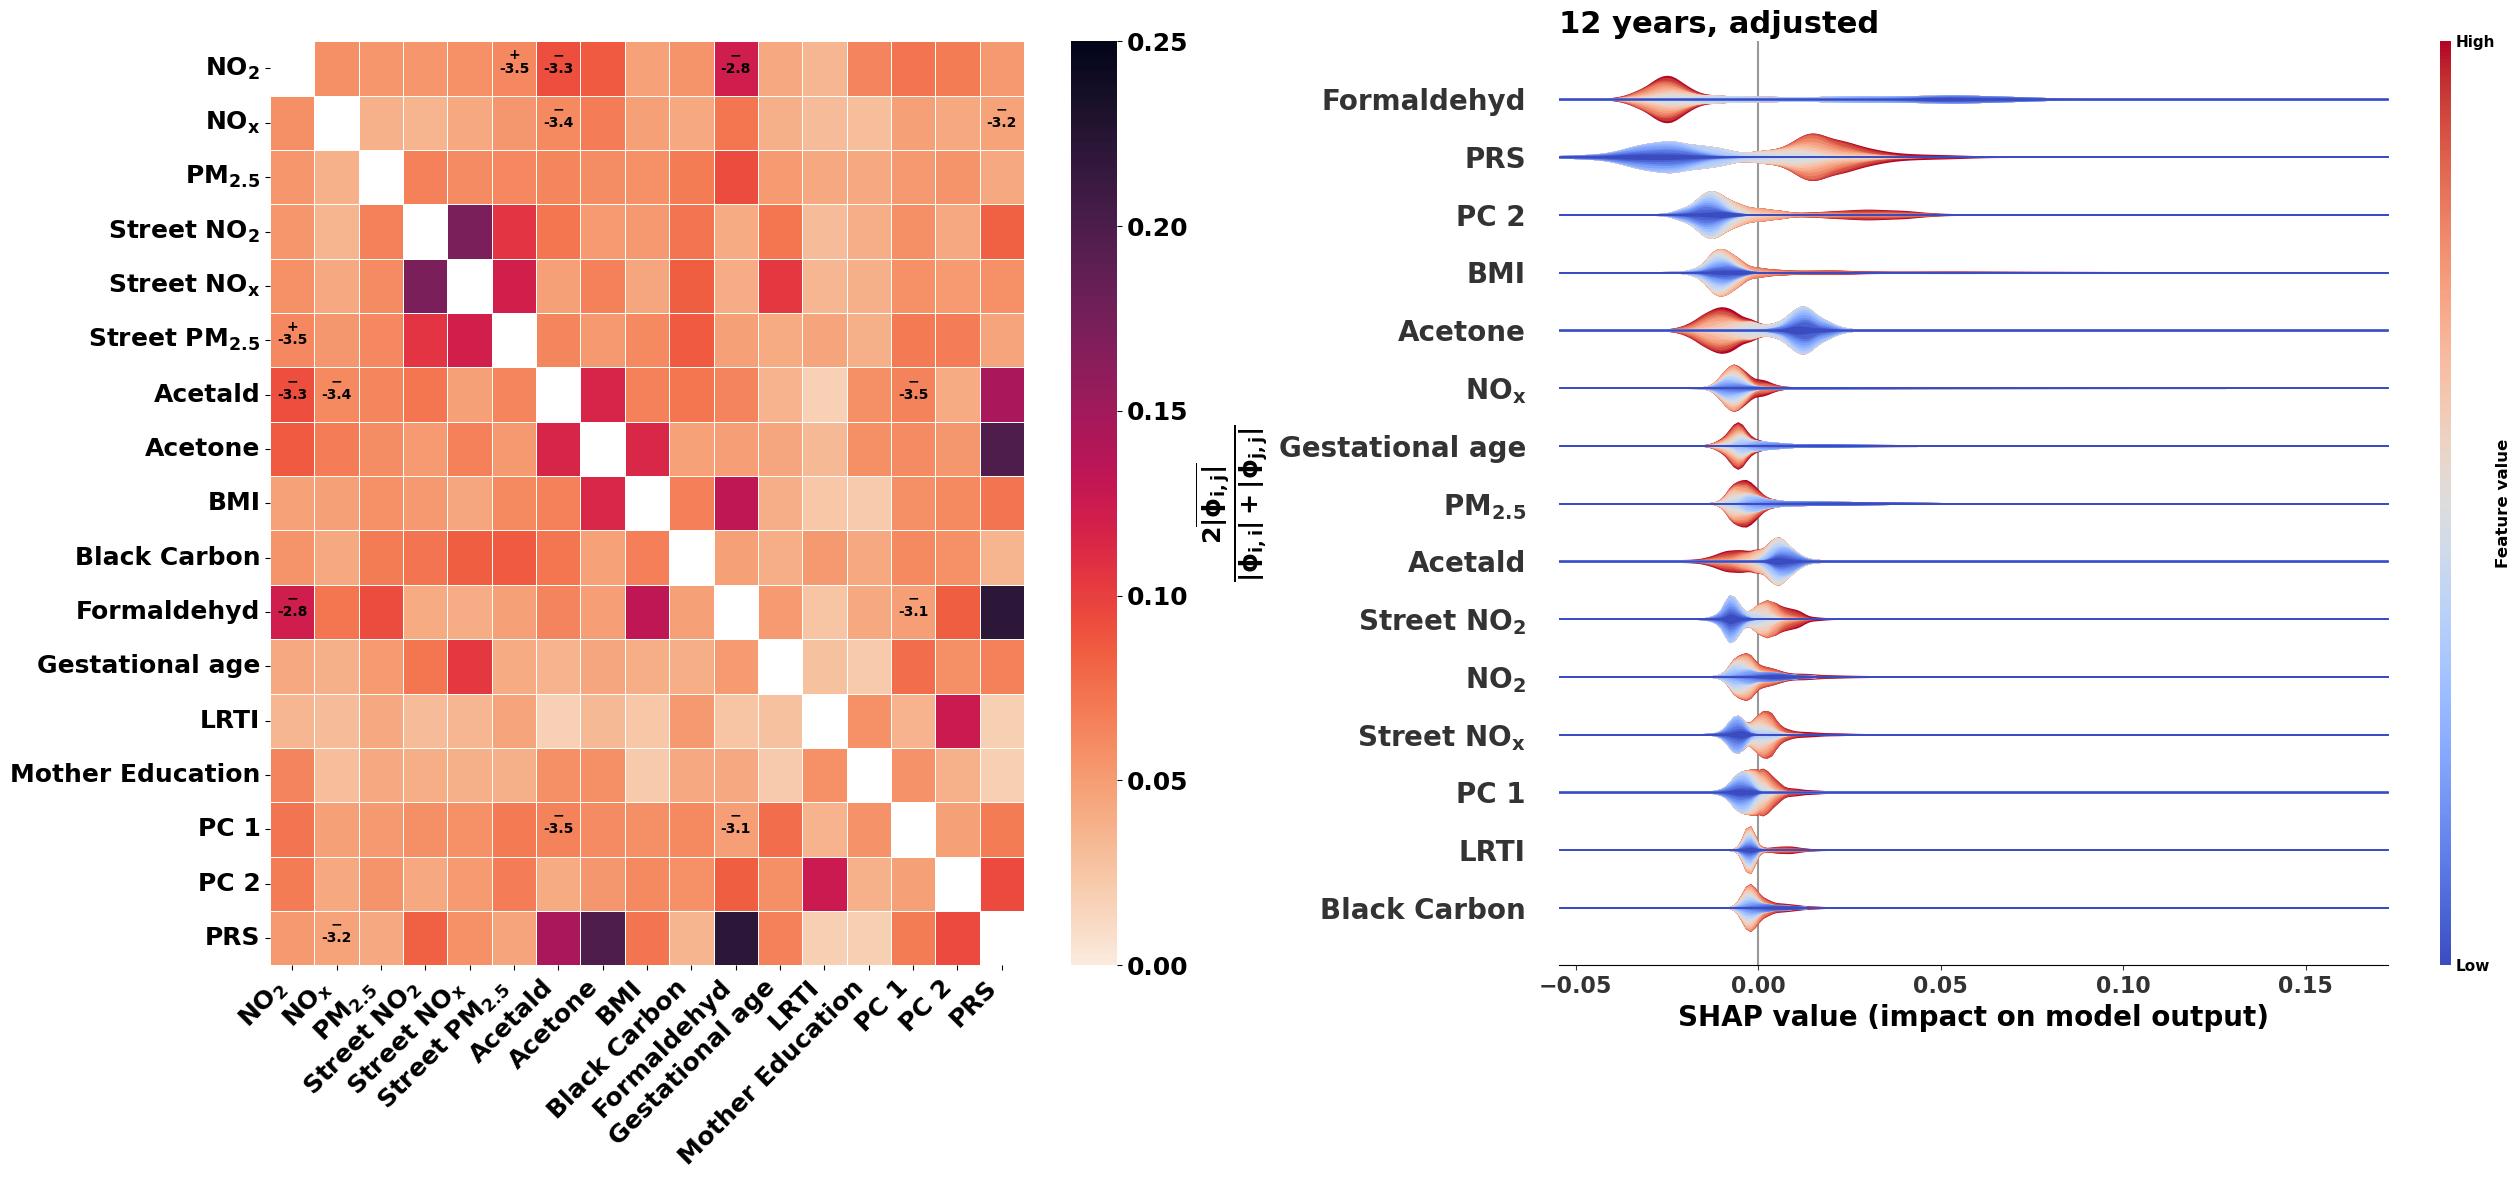

In [29]:

# Swap the columns to create the reverse relationships (B->A, C->A, C->B)
df_flipped = dataframe["interaction_stats"].rename(columns={'feature_i': 'feature_j', 'feature_j': 'feature_i'})

# Combine them together
df_full = pd.concat([dataframe["interaction_stats"], df_flipped]).drop_duplicates()
features_to_drop = ["feature_i", "feature_j"]

matrix_r = df_full.pivot(index='feature_i', columns='feature_j', values='R_mean').rename_axis(None, axis=0).rename_axis(None, axis=1)
matrix_con = df_full.pivot(index='feature_i', columns='feature_j', values='sign_consistency').rename_axis(None, axis=0).rename_axis(None, axis=1)
matrix_effect = df_full.pivot(index='feature_i', columns='feature_j', values='abs_2phi_median').rename_axis(None, axis=0).rename_axis(None, axis=1)
matrix_effect_sign = df_full.pivot(index='feature_i', columns='feature_j', values='signed_2phi_median').rename_axis(None, axis=0).rename_axis(None, axis=1)
dominant_sign= df_full.pivot(index='feature_i', columns='feature_j', values='dominant_sign').rename_axis(None, axis=0).rename_axis(None, axis=1)
plt.rcParams.update({
    "mathtext.default":  "bf",
    "font.weight":       "bold",
    "axes.labelweight":  "bold",
    "axes.titleweight":  "bold",
    "figure.titleweight":"bold",
})
corr_matrix=X.corr(method="spearman")
k = matrix_r.shape[0]

fig = plt.figure(figsize=(30, 12))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.1], wspace=0.35)
ax0, ax1 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

hm = sns.heatmap(matrix_r, cmap="rocket_r", vmin=0, vmax=0.25,
                 linewidths=0.4, linecolor="white", ax=ax0,
                 cbar_kws={'label': r'$\frac{2\overline{|\phi_{i,j}|}}{|\phi_{i,i}|+|\phi_{j,j}|}$'})

norm, cmap = hm.collections[0].norm, hm.collections[0].cmap
for i in range(k):
    for j in range(k): 
        if (matrix_con.iloc[i, j] < 0.8):
            continue
        if np.abs(corr_matrix.loc[matrix_con.columns[i],matrix_con.columns[j]])>0.3:
            continue
        if i==j:
            continue
            
        val = matrix_effect.iloc[i, j]
        sgn = "+" if dominant_sign.iloc[i, j] >= 0 else "\u2212"
        r, g, b, _ = cmap(norm(matrix_r.iloc[i, j]))
        ax0.text(j + 0.5, i + 0.5, f"{np.log10(val):.2}", ha="center", va="center",  fontsize=10, fontweight="bold")
        ax0.text(j + 0.5, i + 0.25, f"{sgn}", ha="center", va="center",
                 fontsize=10, fontweight="bold")      

# ---- heatmap ticks ----
ax0.tick_params(axis="both", labelsize=18)
plt.setp(ax0.get_xticklabels(), rotation=45, ha="right", fontsize=18, fontweight="bold")
plt.setp(ax0.get_yticklabels(), fontsize=18, fontweight="bold")

# ---- colorbar ----
cbar = hm.collections[0].colorbar
cbar.ax.yaxis.label.set(size=26, weight="bold")
cbar.ax.tick_params(labelsize=18)
plt.setp(cbar.ax.get_yticklabels(), fontweight="bold")

# ---- shap panel ----
plt.sca(ax1)
shap.plots.violin(dataframe["shap_explanation"],
                  plot_type="layered_violin",
                  max_display=15, show=False, plot_size=None)
ax1.tick_params(axis="y", labelsize=20)
ax1.tick_params(axis="x", labelsize=16)
plt.setp(ax1.get_yticklabels(), fontsize=20, fontweight="bold")
plt.setp(ax1.get_xticklabels(), fontsize=16, fontweight="bold")
ax1.set_xlabel(ax1.get_xlabel(), fontsize=20, fontweight="bold")
ax1.set_title("12 years, adjusted", loc="left", fontsize=22, pad=6, fontweight="bold")

fig.savefig("../Plots/shap_12_adjusted.png", bbox_inches="tight",dpi=300)  

In [15]:
with open("../Performence/results_rf_12y_adjusted.pkl", "wb") as f:
    pickle.dump(dataframe, f)

In [16]:
val/(2/X.shape[1]**2)

np.float64(0.1019620332972549)

In [23]:
np.abs(corr_matrix.loc["Acetald","Acetone"])>0.3

np.True_